# DM_G3_P0005_transportation_network_answer

## 0. 정답본 범위

- Gate: G3
- Phase: P0005
- Topic: Ch.5 수송·경유수송·할당·최소비용흐름과 Solver 구조
- Problem notebook: `DM_G3_P0005_transportation_network.ipynb`
- Correct answers included: Yes
- Output language: Korean

풀이 전에는 이 정답본을 열지 않는 것을 권장한다.


## 1. 핵심 기준표

| 모형 | 정답의 중심 |
| --- | --- |
| Transportation | 수송량 행렬, 행합=공급, 열합=수요, SUMPRODUCT |
| Assignment | 행합=1, 열합=1, 수송문제 정수해 성질 |
| Transshipment | 경유지 유입=유출 |
| Minimum cost flow | arc table, capacity, node balance |
| SUMIF balance | `SUMIF(start,node,flow)-SUMIF(end,node,flow)` |
| Sensitivity | 경로 reduced cost vs 공급/수요 shadow price |


## 2. 문항별 정답


### 문제 1 정답 — 지역 물류창고 수송계획

총공급량은 `180+220+160=560`, 총수요량은 `140+130+170+120=560`이므로 balanced transportation이다. 변수 `x_ij`는 공급지 `i`에서 수요지 `j`로 보내는 물량이다.

목적함수:

```text
min 6x_A1+8x_A2+10x_A3+9x_A4
  + 9x_B1+7x_B2+4x_B3+5x_B4
  + 8x_C1+6x_C2+7x_C3+6x_C4
```

공급 행합:

```text
x_A1+x_A2+x_A3+x_A4 = 180
x_B1+x_B2+x_B3+x_B4 = 220
x_C1+x_C2+x_C3+x_C4 = 160
```

수요 열합:

```text
x_A1+x_B1+x_C1 = 140
x_A2+x_B2+x_C2 = 130
x_A3+x_B3+x_C3 = 170
x_A4+x_B4+x_C4 = 120
```

Solver mapping:

- changing cells: 3x4 수송량 행렬
- target cell: `SUMPRODUCT(비용행렬, 수송량행렬)`
- constraint LHS cells: 행합 3개, 열합 4개
- RHS cells: 공급량 3개, 수요량 4개

센터 C 공급량이 120이면 총공급은 520, 총수요는 560이다. 수요가 공급보다 40 많으므로 dummy supply 40을 추가한다. 미충족 수요를 허용하는 모델이면 dummy 비용을 큰 페널티로 두고, 단순 균형화용 잔여 처리라면 0 비용을 둘 수 있다. 수송문제는 공급량과 수요량이 정수이면 LP로 풀어도 최적해가 정수로 나오는 성질이 있지만, 이것이 별도의 integer programming 제약을 걸었다는 뜻은 아니다.

비용최소화 수송문제에서 미사용 경로의 reduced cost가 양수이면 그 경로를 사용하면 현재보다 총비용이 그만큼 불리하다는 뜻이다.

- node_id: `n_DM_PDF06.transportation_problem`, `n_DM_PDF06.balanced_transportation`, `n_DM_PDF06.unbalanced_transportation`, `n_DM_PDF06.dummy_supply_or_demand`, `n_DM_PDF06.transportation_solver_model`, `n_DM_PDF06.transportation_integrality`, `n_DM_PDF06.transportation_sensitivity`
- source anchors: `DM_PDF06:p002:L002`, `DM_PDF06:p004:L002`, `DM_PDF06:p005:L002`, `DM_PDF06:p008:L001`, `DM_PDF06:p010:L002`, `DM_PDF06:p010:L013`, `DM_PDF06:p012:L002`, `DM_PDF06:p013:L002`

<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q01:START -->
#### 문항별 시각 학습자료

![DM_G3_P0005_Q01](../visual_assets/item_cards/DM_G3_P0005_Q01.png)

- 노드-간선 경로: `transportation_problem` -> `balanced_transportation` -> `dummy_node`
- 보는 순서: 행은 공급/장비, 열은 수요/작업으로 읽고, 행합과 열합이 어떤 제약을 만드는지 확인한다.
- 그래프 해석: matrix 구조에서 행합/열합이 Solver constraint cells가 되는 과정을 본다.
- 오답 방지: 행합과 열합을 뒤집거나, assignment에서 행/열 제약 중 하나를 누락하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q01:END -->


### 문제 2 정답 — 장비-작업 할당문제

`x_ij=1`이면 장비 `i`를 작업 `j`에 배정하고, `0`이면 배정하지 않는다.

목적함수는 모든 `준비시간_ij * x_ij`의 합을 최소화한다.

장비별 행합:

```text
sum_j x_ij = 1  for each equipment i
```

작업별 열합:

```text
sum_i x_ij = 1  for each job j
```

공급지인 각 장비의 공급량이 1이고 수요지인 각 작업의 수요량도 1이므로 assignment는 특별한 수송문제다. Solver에서는 4x4 matrix를 changing cells로 두고 각 행합과 열합을 1로 제약한다. 수송문제 정수해 성질 때문에 LP relaxation에서도 0/1 해가 보장되는 구조지만, 현실 의미를 명확히 하려면 `x_ij`가 배정 여부를 뜻한다는 0/1 해석을 함께 말해야 한다.

오답 “행합 <= 1이면 충분하고 작업별 제약은 없어도 된다”는 작업이 배정되지 않는 해를 허용한다. 각 장비가 정확히 하나를 하고, 각 작업도 정확히 하나의 장비에 배정되어야 하므로 행합=1과 열합=1이 모두 필요하다.

assignment는 각 작업을 정확히 한 선택으로 덮는다는 점에서 set partitioning과 연결된다.

- node_id: `n_DM_PDF06.assignment_problem`, `n_DM_PDF06.transportation_integrality`
- source anchors: `DM_PDF06:p003:L009`, `DM_PDF06:p015:L002`, `DM_PDF06:p010:L013`

<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q02:START -->
#### 문항별 시각 학습자료

![DM_G3_P0005_Q02](../visual_assets/item_cards/DM_G3_P0005_Q02.png)

- 노드-간선 경로: `assignment_problem` -> `transportation_integrality` -> `row_col_equal_one`
- 보는 순서: 행은 공급/장비, 열은 수요/작업으로 읽고, 행합과 열합이 어떤 제약을 만드는지 확인한다.
- 그래프 해석: matrix 구조에서 행합/열합이 Solver constraint cells가 되는 과정을 본다.
- 오답 방지: 행합과 열합을 뒤집거나, assignment에서 행/열 제약 중 하나를 누락하지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q02:END -->


### 문제 3 정답 — 냉장식품 경유수송

arc flow `x_ij`는 시작노드 `i`에서 종료노드 `j`로 흐르는 물량이다. 목적함수는 arc별 `단위비용 * x_ij`의 합을 최소화한다.

공장 balance:

```text
x13 + x14 = 150
x23 + x24 = 170
```

창고 balance:

```text
x35+x36+x37 - x13 - x23 = 0
x45+x46+x47 - x14 - x24 = 0
```

매장 balance:

```text
x35+x45 = 90
x36+x46 = 110
x37+x47 = 120
```

창고는 물량을 받아 다시 내보내므로 공급지이면서 동시에 수요지처럼 처리된다. 단순 transportation matrix는 공급지 행합과 수요지 열합만 쓰지만, transshipment는 경유 노드에서 유입과 유출을 동시에 맞춰야 한다.

Solver:

- changing cells: arc별 흐름량 열
- target cell: `SUMPRODUCT(단위비용열, 흐름량열)`
- 창고 3 순수유출량: `SUMIF(시작노드,3,흐름량)-SUMIF(종료노드,3,흐름량)=0`
- 창고 4 순수유출량: `SUMIF(시작노드,4,흐름량)-SUMIF(종료노드,4,흐름량)=0`

오답 “창고는 최종 수요가 없으므로 제약식을 쓰지 않아도 된다”는 흐름보존을 누락한다. 창고에 들어온 물량이 사라지거나 창고에서 물량이 새로 생기는 비현실적 해를 허용하게 된다.

- node_id: `n_DM_PDF06.transshipment_problem`, `n_DM_PDF06.transshipment_balance`, `n_DM_PDF06.network_topology_table`, `n_DM_PDF06.sumif_node_balance`
- source anchors: `DM_PDF06:p003:L002`, `DM_PDF06:p017:L002`, `DM_PDF06:p019:L002`, `DM_PDF06:p030:L001`, `DM_PDF06:p031:L002`, `DM_PDF06:p032:L002`

<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q03:START -->
#### 문항별 시각 학습자료

![DM_G3_P0005_Q03](../visual_assets/item_cards/DM_G3_P0005_Q03.png)

- 노드-간선 경로: `transshipment_problem` -> `node_balance` -> `sumif_balance`
- 보는 순서: arc를 먼저 보고, 각 node에서 총유출과 총유입의 차이가 RHS와 맞는지 확인한다.
- 그래프 해석: node balance = outbound - inbound = required net-flow 구조를 본다.
- 오답 방지: 경유지 제약을 생략하거나 SUMIF 시작노드/종료노드 부호를 반대로 쓰지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q03:END -->


### 문제 4 정답 — 최소비용흐름

arc별 changing cells는 `x13, x14, x23, x25, x34, x35, x45`이다. 목적함수는 다음과 같다.

```text
min 5x13+8x14+4x23+7x25+3x34+6x35+2x45
```

capacity constraints:

```text
0<=x13<=30, 0<=x14<=20, 0<=x23<=25, 0<=x25<=30,
0<=x34<=25, 0<=x35<=30, 0<=x45<=20
```

node balance는 `총유출량-총유입량=의무유출량`이다.

```text
node1: x13+x14 = 35
node2: x23+x25 = 25
node3: x34+x35 - x13 - x23 = 0
node4: x45 - x14 - x34 = -20
node5: -x25 - x35 - x45 = -40
```

노드 1,2는 supply node, 노드 4,5는 demand node, 노드 3은 transshipment node다. transportation은 공급지-수요지 matrix의 행합/열합으로 충분하지만, minimum cost flow는 일반 arc table과 node balance, capacity가 필요하다.

Solver:

- target cell: `SUMPRODUCT(cost, flow)`
- changing cells: arc flow column
- constraint cells: arc capacity, node net outflow
- RHS cells: capacity column, required net-flow column

오답 “모든 노드는 유출량이 유입량보다 커야 한다”는 demand node의 음수 RHS를 무시한다. 수요 노드는 유입이 유출보다 커야 하므로 순수유출량이 음수다.

- node_id: `n_DM_PDF06.minimum_cost_flow`, `n_DM_PDF06.network_topology_table`, `n_DM_PDF06.sumif_node_balance`, `n_DM_PDF02.shadow_price`, `n_DM_PDF02.reduced_cost`
- source anchors: `DM_PDF06:p022:L002`, `DM_PDF06:p025:L002`, `DM_PDF06:p026:L002`, `DM_PDF06:p030:L001`, `DM_PDF06:p031:L002`, `DM_PDF06:p032:L002`

<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q04:START -->
#### 문항별 시각 학습자료

![DM_G3_P0005_Q04](../visual_assets/item_cards/DM_G3_P0005_Q04.png)

- 노드-간선 경로: `minimum_cost_flow` -> `capacity` -> `required_net_flow`
- 보는 순서: arc를 먼저 보고, 각 node에서 총유출과 총유입의 차이가 RHS와 맞는지 확인한다.
- 그래프 해석: node balance = outbound - inbound = required net-flow 구조를 본다.
- 오답 방지: 경유지 제약을 생략하거나 SUMIF 시작노드/종료노드 부호를 반대로 쓰지 않는다.
<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q04:END -->


### 문제 5 정답 — 수송문제 민감도 해석

비용최소화 문제에서 미사용 경로 A→지역3의 reduced cost=4는 해당 경로를 1단위 사용하면 현재 최적 총비용보다 4만큼 불리하다는 뜻이다. 단위비용이 10에서 7로 낮아지는 것은 3만큼의 감소이며 allowable decrease 4 안에 있으므로 현재 basis는 유지된다.

센터 B 공급량이 10 증가하고 허용범위 안이라면 총비용 변화는 다음과 같다.

```text
10 * (-2) = -20
```

즉 더 유리한 공급원이 늘어 총비용이 20 감소한다. 지역 4 수요가 15 증가하고 허용범위 안이라면 총비용 변화는 다음과 같다.

```text
15 * 5 = 75
```

reduced cost는 경로 변수 질문이고, shadow price는 공급량/수요량 제약 RHS 질문이다.

- node_id: `n_DM_PDF06.transportation_sensitivity`, `n_DM_PDF02.reduced_cost`, `n_DM_PDF02.shadow_price`
- source anchors: `DM_PDF06:p012:L002`, `DM_PDF06:p013:L002`, `DM_PDF06:p014:L002`, `DM_PDF02:p032:L002`

<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q05:START -->
#### 문항별 시각 학습자료

![DM_G3_P0005_Q05](../visual_assets/item_cards/DM_G3_P0005_Q05.png)

- 노드-간선 경로: `transportation_sensitivity` -> `reduced_cost` -> `shadow_price`
- 보는 순서: 노드-간선 흐름을 왼쪽에서 오른쪽으로 따라가며 현재 문항의 판정 질문을 확인한다.
- 그래프 해석: 최적해 이론의 핵심 판정 신호가 그래프에서 어디에 나타나는지 본다.
- 오답 방지: 계산 결과만 보지 말고 어떤 노드에서 어떤 노드로 이동하는지 설명한다.
<!-- ITEM_VISUAL_CARD:DM_G3_P0005_Q05:END -->


## 2.5 시각화 심화 학습 보드

아래 코드는 행합/열합 수송모형과 node balance 네트워크 모형의 차이를 시각적으로 보여준다. 그림 내부 텍스트는 폰트 깨짐 방지를 위해 영어로 표시한다.


In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch, Circle

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.unicode_minus": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 10,
})

def box(ax, x, y, w, h, text, fc="#eef6ff", ec="#27343a", fs=8.5):
    ax.add_patch(Rectangle((x, y), w, h, facecolor=fc, edgecolor=ec, lw=1.3))
    ax.text(x+w/2, y+h/2, text, ha="center", va="center", fontsize=fs)

def arrow(ax, a, b, color="#2563eb"):
    ax.add_patch(FancyArrowPatch(a, b, arrowstyle="-|>", mutation_scale=13, lw=1.5, color=color))

def flow(ax, rows, title):
    ax.axis("off")
    ax.set_title(title)
    colors = ["#e7f0fd", "#e9f7ef", "#fff4d6", "#fce8e6", "#ece7fb", "#e8f6f8"]
    centers = []
    for i, row in enumerate(rows):
        y = 0.88 - i * (0.76 / max(len(rows)-1, 1))
        m = len(row)
        row_centers = []
        for j, text in enumerate(row):
            x = 0.08 + j * (0.78 / max(m-1, 1)) if m > 1 else 0.38
            box(ax, x, y-0.055, 0.25, 0.11, text, fc=colors[(i+j)%len(colors)])
            row_centers.append((x+0.125, y))
        centers.append(row_centers)
    for i in range(len(centers)-1):
        for a in centers[i]:
            for b in centers[i+1]:
                if len(centers[i]) == 1 or len(centers[i+1]) == 1 or abs(a[0]-b[0]) < 0.3:
                    arrow(ax, (a[0], a[1]-0.06), (b[0], b[1]+0.06))

print("visual setup ready:", mpl.rcParams["font.family"][0])


visual setup ready: DejaVu Sans


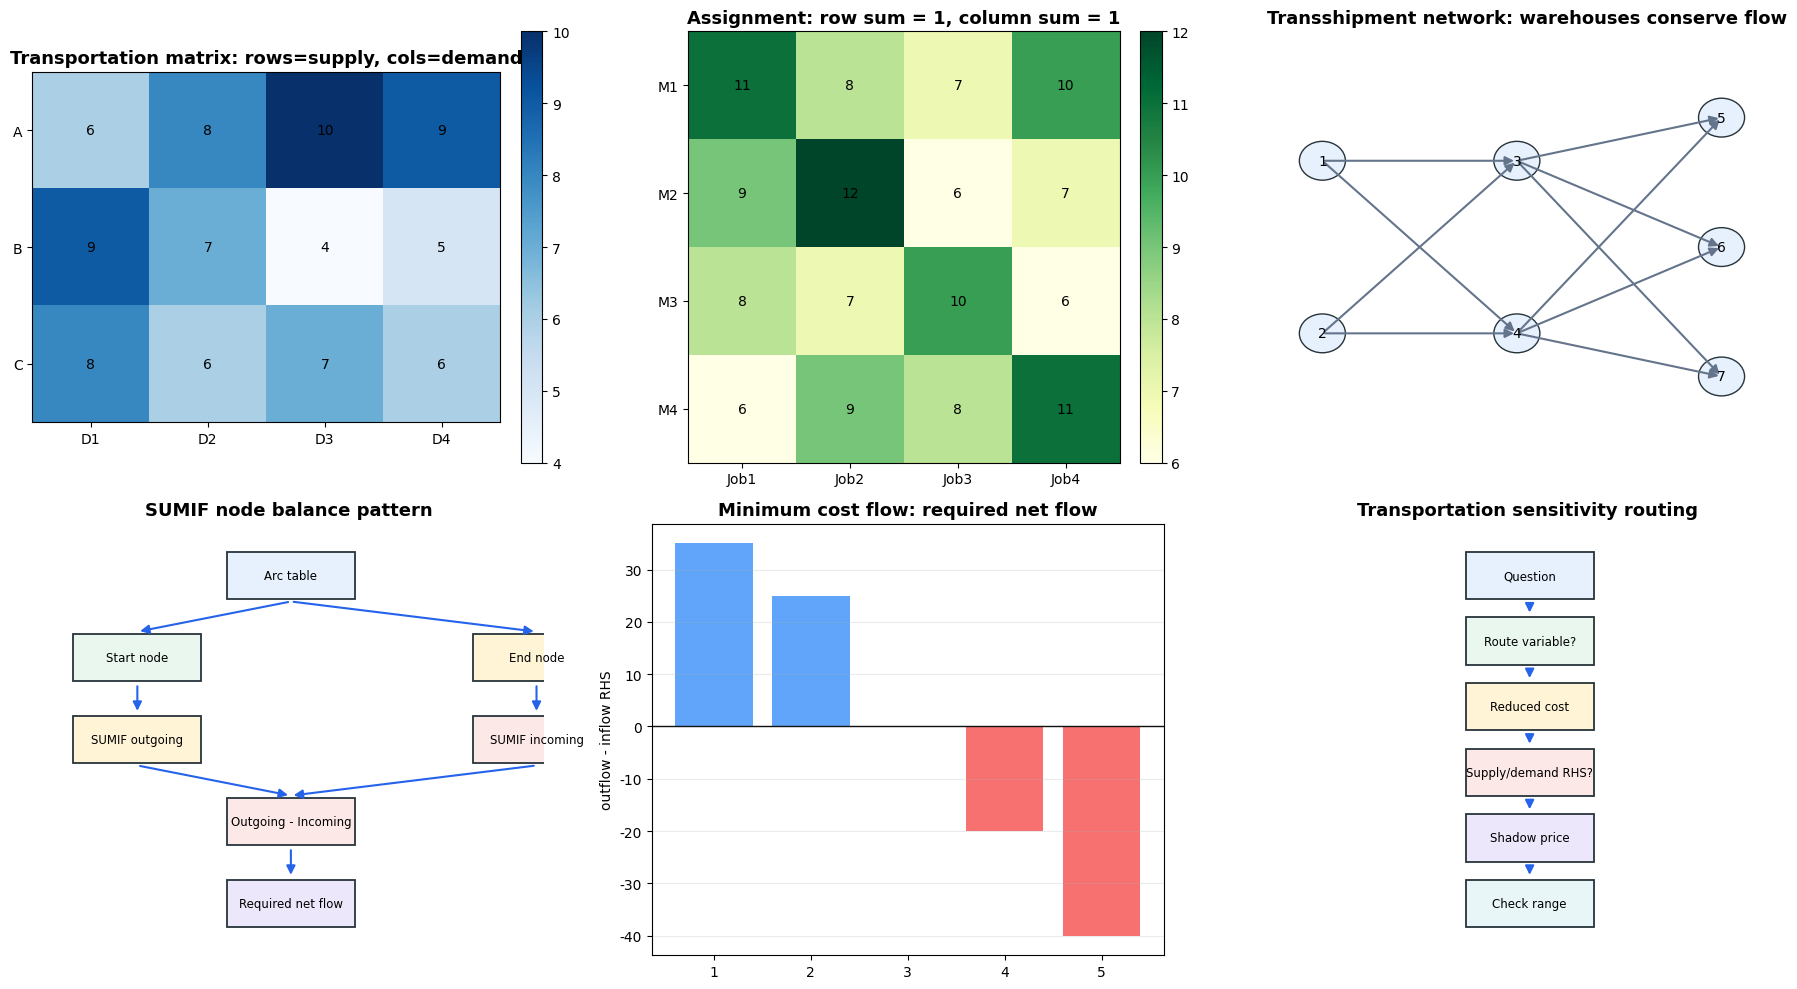

In [2]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0,0]
cost = np.array([[6,8,10,9],[9,7,4,5],[8,6,7,6]], dtype=float)
im = ax.imshow(cost, cmap="Blues")
ax.set_xticks(range(4)); ax.set_xticklabels(["D1","D2","D3","D4"])
ax.set_yticks(range(3)); ax.set_yticklabels(["A","B","C"])
for i in range(3):
    for j in range(4):
        ax.text(j,i,f"{cost[i,j]:.0f}",ha="center",va="center")
ax.set_title("Transportation matrix: rows=supply, cols=demand")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[0,1]
assign = np.array([[11,8,7,10],[9,12,6,7],[8,7,10,6],[6,9,8,11]], dtype=float)
im = ax.imshow(assign, cmap="YlGn")
ax.set_xticks(range(4)); ax.set_xticklabels(["Job1","Job2","Job3","Job4"])
ax.set_yticks(range(4)); ax.set_yticklabels(["M1","M2","M3","M4"])
for i in range(4):
    for j in range(4):
        ax.text(j,i,f"{assign[i,j]:.0f}",ha="center",va="center")
ax.set_title("Assignment: row sum = 1, column sum = 1")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax = axes[0,2]
ax.axis("off")
pos={1:(0.1,0.7),2:(0.1,0.3),3:(0.48,0.7),4:(0.48,0.3),5:(0.88,0.8),6:(0.88,0.5),7:(0.88,0.2)}
for n,(x,y) in pos.items():
    ax.add_patch(Circle((x,y),0.045,fc="#e7f0fd",ec="#27343a"))
    ax.text(x,y,str(n),ha="center",va="center")
for a,b in [(1,3),(1,4),(2,3),(2,4),(3,5),(3,6),(3,7),(4,5),(4,6),(4,7)]:
    arrow(ax,pos[a],pos[b],color="#64748b")
ax.set_title("Transshipment network: warehouses conserve flow")

ax = axes[1,0]
ax.axis("off")
flow(ax, [
    ["Arc table"],
    ["Start node", "End node"],
    ["SUMIF outgoing", "SUMIF incoming"],
    ["Outgoing - Incoming"],
    ["Required net flow"]
], "SUMIF node balance pattern")

ax = axes[1,1]
nodes=["1","2","3","4","5"]
req=[35,25,0,-20,-40]
colors=["#60a5fa" if v>0 else "#f87171" if v<0 else "#facc15" for v in req]
ax.bar(nodes, req, color=colors)
ax.axhline(0,color="#111",lw=1)
ax.set_title("Minimum cost flow: required net flow")
ax.set_ylabel("outflow - inflow RHS")
ax.grid(axis="y",alpha=0.25)

ax = axes[1,2]
ax.axis("off")
flow(ax, [
    ["Question"],
    ["Route variable?"],
    ["Reduced cost"],
    ["Supply/demand RHS?"],
    ["Shadow price"],
        ["Check range"]
], "Transportation sensitivity routing")

plt.tight_layout()
plt.show()


## 3. 채점 기준

- transportation formulation과 Solver mapping: 20점
- balanced/unbalanced/dummy 처리: 15점
- assignment formulation: 15점
- transshipment node balance: 20점
- minimum cost flow와 SUMIF balance: 20점
- sensitivity 연결과 오답진단: 10점


## 4. 오답튜터 기준표

| 오류 | 피드백 기준 |
| --- | --- |
| 행합과 열합을 뒤집음 | 공급지는 행합, 수요지는 열합으로 다시 매핑시킨다. |
| 공급/수요 제약 방향 오류 | balanced면 등식, unbalanced면 dummy 또는 부등호 해석을 구분한다. |
| dummy node를 실제 시설로 해석 | 균형화를 위한 가상 노드임을 설명한다. |
| assignment에서 행합/열합 중 하나 누락 | 1:1 배정에는 둘 다 필요하다고 교정한다. |
| binary와 정수해 성질 혼동 | LP 구조상 정수해가 보장되는 것과 의미상 0/1 변수를 구분한다. |
| 경유지 balance 누락 | 창고 유입=유출 조건을 반드시 세운다. |
| SUMIF 부호 반대 | `시작노드 합 - 종료노드 합` 순서를 유지하게 한다. |
| node balance RHS 부호 오류 | 공급은 양수, 수요는 음수, 경유는 0으로 해석한다. |
| reduced cost/shadow price 혼동 | 경로 변수 질문과 공급/수요 RHS 질문을 분리한다. |
| shadow price 범위 밖 적용 | 허용범위 밖이면 재최적화가 필요하다고 교정한다. |


## 5. 다음 Phase 연결

다음 Phase는 integer programming, binary variable, LP relaxation으로 연결된다. assignment의 0/1 해석과 네트워크 integrality를 이해하면 정수계획에서 “왜 단순 반올림이 위험한가”를 더 명확히 볼 수 있다.
